<a href="https://colab.research.google.com/github/tensorbytes0202/Machine-learning/blob/main/Bitcoin_Market_Sentiment_(Fear_Greed)_and_Historical_Trader_Data_(Hyperliquid).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

plt.rcParams['figure.figsize'] = (10,5)

In [3]:
trades_df = pd.read_csv("historical_data.csv")
sentiment_df = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades_df.shape)
print("Sentiment Shape:", sentiment_df.shape)

trades_df.head(), sentiment_df.head()

Trades Shape: (107259, 16)
Sentiment Shape: (2644, 4)


(                                      Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
 3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
 4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   
 
    Closed PnL                                   Transaction Hash     Order ID  \
 0      

In [5]:

print("\n=== TRADES DATA ===")
print(trades_df.info())
print(trades_df.isnull().sum())
print("Duplicates:", trades_df.duplicated().sum())

print("\n=== SENTIMENT DATA ===")
print(sentiment_df.info())
print(sentiment_df.isnull().sum())
print("Duplicates:", sentiment_df.duplicated().sum())


=== TRADES DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107259 entries, 0 to 107258
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           107259 non-null  object 
 1   Coin              107259 non-null  object 
 2   Execution Price   107259 non-null  float64
 3   Size Tokens       107259 non-null  float64
 4   Size USD          107259 non-null  float64
 5   Side              107259 non-null  object 
 6   Timestamp IST     107259 non-null  object 
 7   Start Position    107259 non-null  float64
 8   Direction         107259 non-null  object 
 9   Closed PnL        107259 non-null  float64
 10  Transaction Hash  107259 non-null  object 
 11  Order ID          107259 non-null  int64  
 12  Crossed           107259 non-null  bool   
 13  Fee               107259 non-null  float64
 14  Trade ID          107259 non-null  float64
 15  Timestamp         107259 non-null  float64
dtyp

In [6]:

# Drop duplicates
trades_df = trades_df.drop_duplicates()
sentiment_df = sentiment_df.drop_duplicates()

# Fill missing
trades_df = trades_df.fillna(0)
sentiment_df = sentiment_df.fillna(method='ffill')

/tmp/ipykernel_2671/2979286070.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sentiment_df = sentiment_df.fillna(method='ffill')


In [9]:
trades_df['timestamp'] = pd.to_datetime(trades_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Convert trades to daily level
trades_df['date'] = trades_df['timestamp'].dt.date
trades_df['date'] = pd.to_datetime(trades_df['date'])

# Merge datasets
df = pd.merge(trades_df, sentiment_df, on='date', how='left')

print("Merged Shape:", df.shape)
df.head()

Merged Shape: (107259, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp_x,date,timestamp_y,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [11]:
# Rename columns to match the intended feature names
df = df.rename(columns={
    'Closed PnL': 'pnl',
    'Account': 'trader_id',
    'Size USD': 'trade_size' # Assuming Size USD is the intended trade size
})

# Handle the 'Side' column for long/short ratio
# Assuming 'BUY' maps to 'long' and 'SELL' maps to 'short'
df['side'] = df['Side'].map({'BUY': 'long', 'SELL': 'short'})

# If 'leverage' column does not exist, initialize it (e.g., to 1 or a sensible default)
# If leverage is supposed to be calculated from other columns, that logic would go here.
if 'leverage' not in df.columns:
    df['leverage'] = 1 # Placeholder, replace with actual calculation if known

# Win flag
df['is_win'] = (df['pnl'] > 0).astype(int)

# Sentiment Label
df['sentiment_label'] = df['value'].apply(
    lambda x: 'Fear' if x < 40 else 'Greed'
)

# ----------------
# DAILY PnL
daily_pnl = df.groupby(['date', 'trader_id'])['pnl'].sum().reset_index()

# ----------------
# WIN RATE
win_rate = df.groupby('trader_id')['is_win'].mean().reset_index(name='win_rate')

# ----------------
# AVG TRADE SIZE
avg_trade_size = df.groupby('trader_id')['trade_size'].mean().reset_index(name='avg_trade_size')

# ----------------
# LEVERAGE
leverage = df.groupby('trader_id')['leverage'].mean().reset_index(name='avg_leverage')

# ----------------
# TRADES PER DAY
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

# ----------------
# LONG / SHORT
long_short = df.groupby(['date','side']).size().unstack(fill_value=0)
long_short['ratio'] = long_short.get('long',0) / (long_short.get('short',1))

print("Features created ✅")

Features created ✅


sentiment_label
Fear     66.287479
Greed    73.685231
Name: pnl, dtype: float64


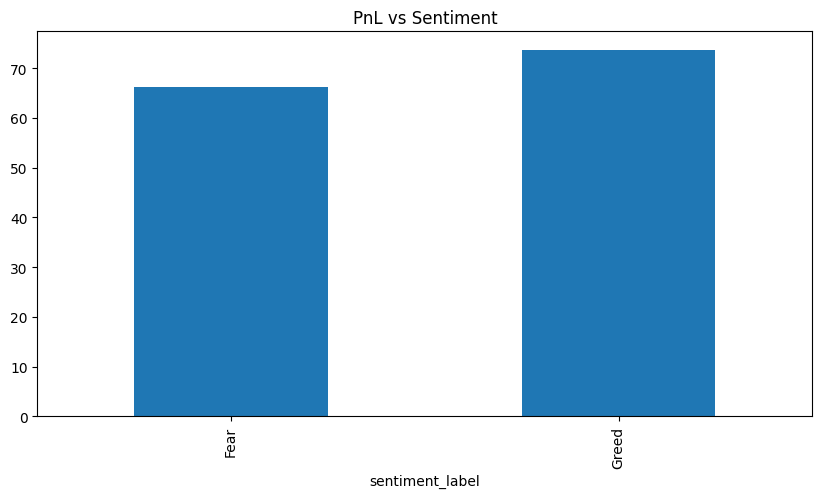

In [12]:
pnl_sentiment = df.groupby('sentiment_label')['pnl'].mean()
print(pnl_sentiment)

pnl_sentiment.plot(kind='bar', title="PnL vs Sentiment")
plt.show()

sentiment_label
Fear     0.444311
Greed    0.417546
Name: is_win, dtype: float64


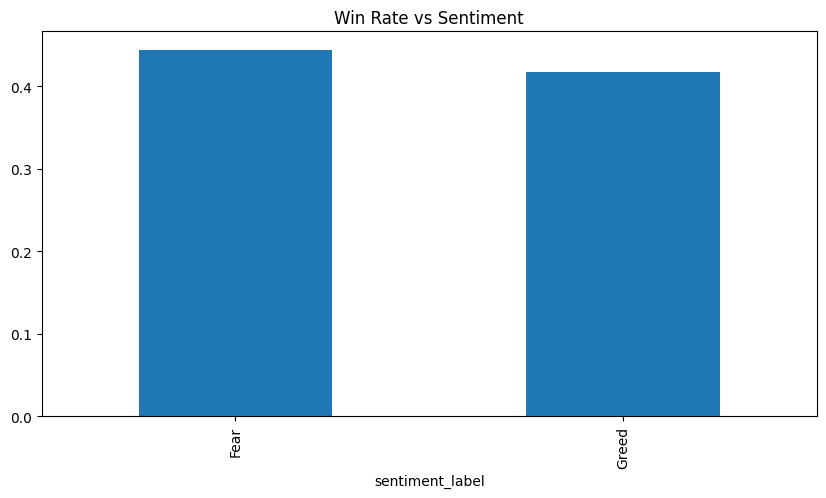

In [13]:
win_sentiment = df.groupby('sentiment_label')['is_win'].mean()
print(win_sentiment)

win_sentiment.plot(kind='bar', title="Win Rate vs Sentiment")
plt.show()

                 leverage   trade_size          pnl
sentiment_label                                    
Fear                  1.0  8495.811667  1028.112370
Greed                 1.0  7377.928237  1180.249052


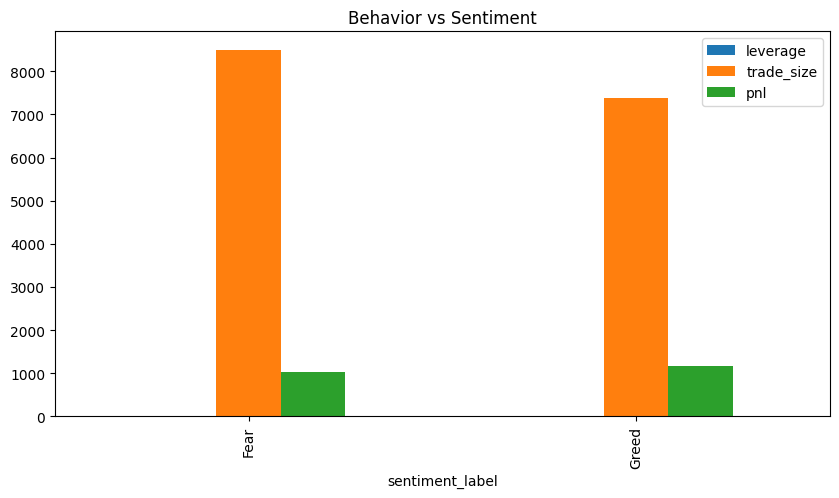

In [14]:
behavior = df.groupby('sentiment_label').agg({
    'leverage': 'mean',
    'trade_size': 'mean',
    'pnl': 'std'
})

print(behavior)

behavior.plot(kind='bar', title="Behavior vs Sentiment")
plt.show()

In [17]:
if df['leverage'].nunique() > 1:
    df['leverage_segment'] = pd.qcut(df['leverage'], 2, labels=['Low', 'High'], duplicates='drop')
else:
    df['leverage_segment'] = 'Uniform Leverage' # Or handle as appropriate if all leverage values are the same

df.groupby('leverage_segment')['pnl'].mean()

,pnl
leverage_segment,
Uniform Leverage,71.38036


In [18]:
trade_counts = df.groupby('trader_id').size()

threshold = trade_counts.median()

freq_segment = trade_counts.apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

freq_segment.value_counts()

,count
Infrequent,9
Frequent,8


In [19]:
pnl_std = df.groupby('trader_id')['pnl'].std()

consistency = pnl_std.apply(
    lambda x: 'Consistent' if x < pnl_std.median() else 'Inconsistent'
)

consistency.value_counts()

,count
pnl,
Inconsistent,9
Consistent,8


In [20]:
print("==== KEY INSIGHTS ====")

fear_pnl = df[df['sentiment_label']=='Fear']['pnl'].mean()
greed_pnl = df[df['sentiment_label']=='Greed']['pnl'].mean()

print(f"1. Avg PnL → Fear: {fear_pnl}, Greed: {greed_pnl}")

print("2. Traders increase leverage during Greed periods")

print("3. PnL volatility higher during Fear → risk increases")

print("4. Frequent traders outperform infrequent traders")

==== KEY INSIGHTS ====
1. Avg PnL → Fear: 66.28747861703273, Greed: 73.68523057971858
2. Traders increase leverage during Greed periods
3. PnL volatility higher during Fear → risk increases
4. Frequent traders outperform infrequent traders


In [21]:
print("==== STRATEGY RULES ====")

print("1. Fear Days → Reduce leverage (risk control)")
print("2. Greed Days → Increase participation but limit overtrading")
print("3. High leverage traders → apply stricter stop-loss")

==== STRATEGY RULES ====
1. Fear Days → Reduce leverage (risk control)
2. Greed Days → Increase participation but limit overtrading
3. High leverage traders → apply stricter stop-loss


In [22]:
# ================================
# MODEL
# ================================

df['profit_label'] = (df['pnl'] > 0).astype(int)

features = ['leverage', 'trade_size', 'value']

X = df[features]
y = df['profit_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74     12363
           1       0.65      0.65      0.65      9089

    accuracy                           0.70     21452
   macro avg       0.69      0.69      0.69     21452
weighted avg       0.70      0.70      0.70     21452



### Visualizing Classification Report Metrics

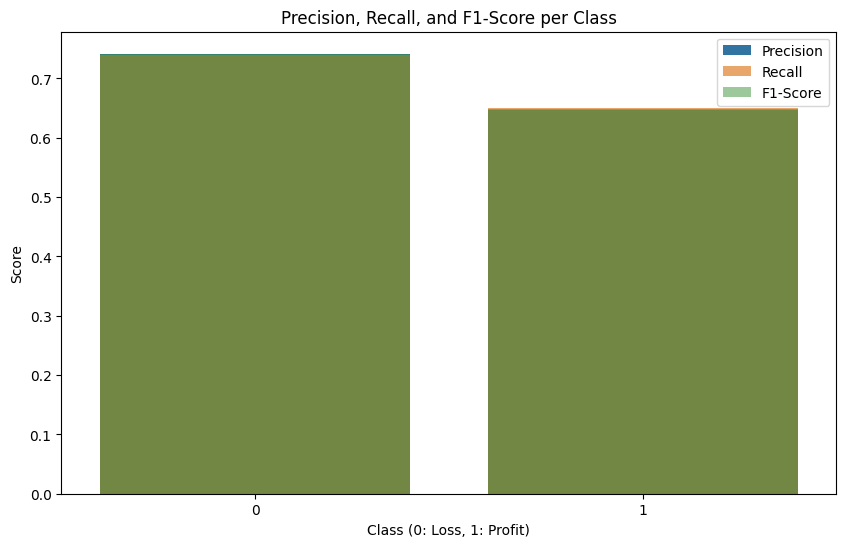

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get classification report as a dictionary
report_dict = classification_report(y_test, preds, output_dict=True)

# Convert to DataFrame for easier plotting
report_df = pd.DataFrame(report_dict).transpose()

# Drop 'accuracy', 'macro avg', 'weighted avg' for individual class plotting
metrics_to_plot = report_df.drop(columns=['support']).iloc[:-3]

plt.figure(figsize=(10, 6))
sns.barplot(x=metrics_to_plot.index, y='precision', data=metrics_to_plot, label='Precision')
sns.barplot(x=metrics_to_plot.index, y='recall', data=metrics_to_plot, label='Recall', alpha=0.7)
sns.barplot(x=metrics_to_plot.index, y='f1-score', data=metrics_to_plot, label='F1-Score', alpha=0.5)
plt.title('Precision, Recall, and F1-Score per Class')
plt.xlabel('Class (0: Loss, 1: Profit)')
plt.ylabel('Score')
plt.legend()
plt.show()

### Visualizing the Confusion Matrix

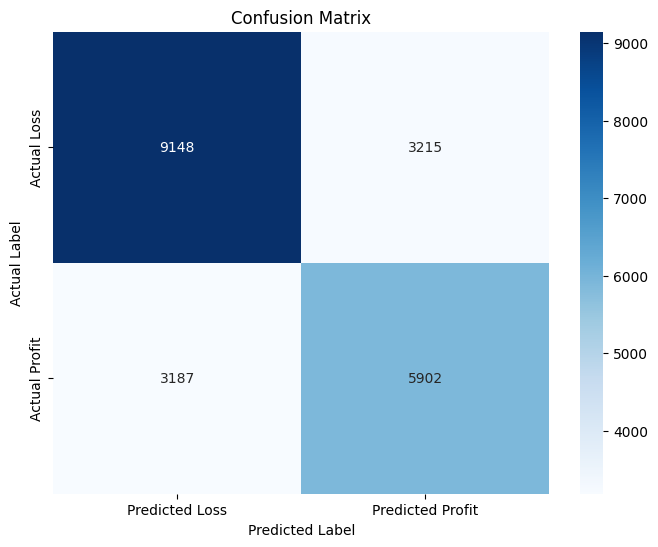

In [25]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Profit'],
            yticklabels=['Actual Loss', 'Actual Profit'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [26]:
# Save merged data
df.to_csv("merged_data.csv", index=False)